# Autocorrelation function (ACF) curve analysis

This is a notebook to analyze ACF curves generated by x-translation. Follow the instructions and run each code cell successively.

## 0. Data upload and notebook setup
Start by uploading the ACF tables to a Google Drive folder. Make sure this folder contains no other files beside the tables.

In [16]:
#@title Link Google Colaboratory to Drive account to access files

from google.colab import drive
drive.mount('/content/drive')

file_root = '/content/drive/My Drive/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load data

Type in the path to the folder with the ACF tables.

In [29]:
path = "/content/drive/MyDrive/MIE/ACF tables/" # @param {"type":"string"}
path1 = path + "*"

## 2. Specify experimental conditions

In the cell below, generate a list of the different experimental conditions to group data based on the ACF tables filenames. The names of the conditions will be identified in the filenames and assigned to each data entry.

Format the list as follows:

condition_names = ["Condition_A", "Condition_B", "Condition_C"]

In [30]:
condition_names = ["Basal", "15min", "60min"]

In [31]:
#@title Assign experimental condition to each data entry
import os
import glob
import numpy as np
import pandas as pd

# List csv files
tables = glob.glob(os.path.join(path, "*.csv"))

# Read and concatenate
dfs = []

for file in tables:
    table = pd.read_csv(file)

    # Add ROI column from filename
    table["ROI"] = os.path.basename(file)

    dfs.append(table)

# Combined dataframe
data = pd.concat(dfs, ignore_index=True)

# Assign condition based on ROI name
conditions = [
    data["ROI"].str.contains(condition, regex=False, na=False)
    for condition in condition_names
]

data["Condition"] = np.select(
    conditions,
    condition_names,
    default="Unknown"
)

# Convert to ordered categorical
data["Condition"] = pd.Categorical(
    data["Condition"],
    categories=condition_names + ["Unknown"],
    ordered=True
)
print(data.head())

   Translation  Pearson                  ROI Condition
0          -20      NaN  C1-Basal_331_21.csv     Basal
1          -19      NaN  C1-Basal_331_21.csv     Basal
2          -18      NaN  C1-Basal_331_21.csv     Basal
3          -17      NaN  C1-Basal_331_21.csv     Basal
4          -16      NaN  C1-Basal_331_21.csv     Basal


## 3. Filter data

In [32]:
#@title Discard noisy ACF profiles (diff between max and min Pearson > 1) and profiles with missing values.

# Identify ROIs with NaN values in Pearson
roi_has_nan = data.groupby("ROI")["Pearson"].apply(lambda x: x.isna().any())

# Calculate Pearson range for each ROI
roi_range = data.groupby("ROI")["Pearson"].agg(
    lambda x: x.max(skipna=True) - x.min(skipna=True)
)

# Identify noisy ROIs to remove
rois_to_remove = roi_has_nan | (roi_range > 1)

# Remove all rows belonging to those ROIs
data_filtered = data[
    ~data["ROI"].isin(rois_to_remove[rois_to_remove].index)
].copy()

## 4. Plot all ACF curves

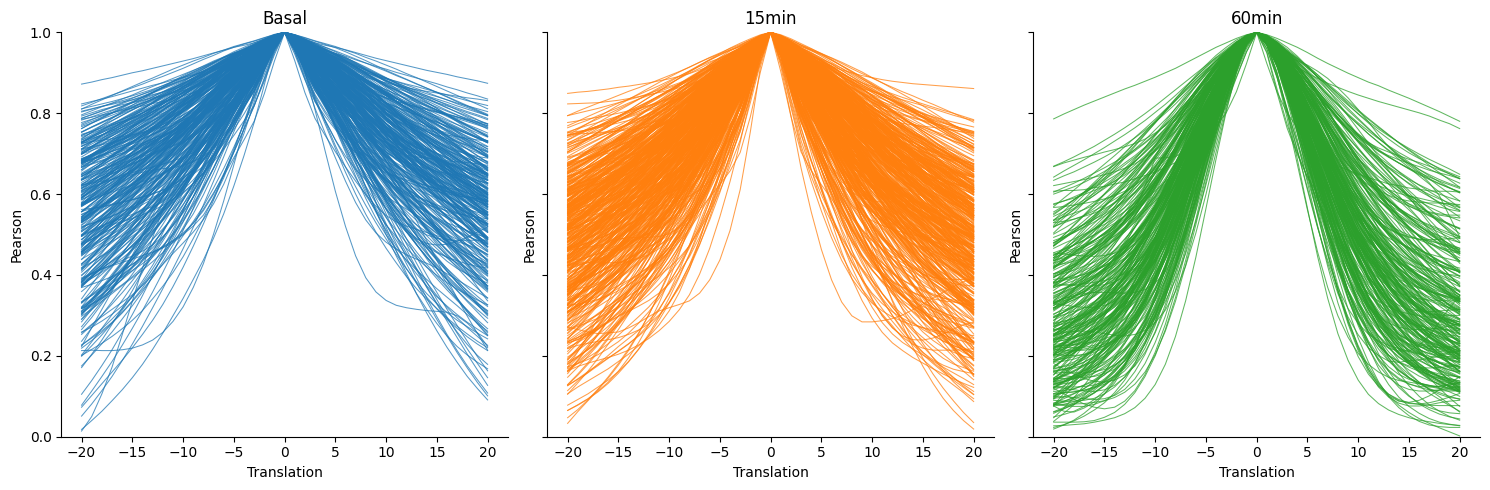

In [33]:
#@title Plot all ACF curves, separated by condition.

import matplotlib.pyplot as plt
import seaborn as sns

# Get conditions that are actually present in the data
conditions = data_filtered["Condition"].dropna().unique()

# Create one subplot per condition
fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(5 * len(conditions), 5),
    sharex=True,
    sharey=True
)

# Make sure axes is iterable when there is only one condition
if len(conditions) == 1:
    axes = [axes]

# Generate automatic colors
palette = sns.color_palette("tab10", n_colors=len(conditions))
colors = dict(zip(conditions, palette))

# Plot each condition
for ax, cond in zip(axes, conditions):

    condition_data = data_filtered[
        data_filtered["Condition"] == cond
    ]

    # Plot one ROI at a time
    for roi, df_sub in condition_data.groupby("ROI"):

        ax.plot(
            df_sub["Translation"],
            df_sub["Pearson"],
            alpha=0.75,
            linewidth=0.75,
            color=colors[cond]
        )

    ax.set_title(str(cond))
    ax.set_xlabel("Translation")
    ax.set_ylabel("Pearson")

    ax.set_ylim(0, 1)

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## 5. Fit curves to double Gaussian

The next code chunk fits each ACF curve to a double Gaussian:

$$ \text{Pearson} = A \cdot e^\frac{{-\text{Translation}^2}}{2\sigma_1^2} + (1-A) \cdot e^\frac{{-\text{Translation}^2}}{2\sigma_2^2}$$

In [34]:
#@title Double Gaussian fitting

from scipy.optimize import curve_fit

# Define double Gaussian model
def double_gaussian(x, A, sigma1, sigma2):
    return (
        A * np.exp(-(x**2)/(2*sigma1**2))
        + (1 - A) * np.exp(-(x**2)/(2*sigma2**2))
    )

def fit_double_gaussian(df):

    df = df.dropna(subset=["Translation", "Pearson"])

    if len(df) < 6:
        return {
            "A": np.nan,
            "sigma1": np.nan,
            "sigma2": np.nan
        }

    x = df["Translation"].values
    y = df["Pearson"].values

    try:

        # Starting parameters
        p0 = [
            0.6,
            np.std(x) / 2,
            np.std(x) * 2
        ]

        params, _ = curve_fit(
            double_gaussian,
            x,
            y,
            p0=p0,
            maxfev=5000
        )

        A, sigma1, sigma2 = params

        # Enforce ordering
        if sigma1 > sigma2:
            sigma1, sigma2 = sigma2, sigma1

        return {
            "A": A,
            "sigma1": sigma1,
            "sigma2": sigma2
        }

    except RuntimeError:

        return {
            "A": np.nan,
            "sigma1": np.nan,
            "sigma2": np.nan
        }


# Fit per condition + ROI
results = []

for (cond, roi), df_sub in data_filtered.groupby(
    ["Condition", "ROI"]
):

    fit = fit_double_gaussian(df_sub)

    fit["Condition"] = cond
    fit["ROI"] = roi

    results.append(fit)

results2 = pd.DataFrame(results)

print(results2.head())

/tmp/ipykernel_861/121858690.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (cond, roi), df_sub in data_filtered.groupby(
/tmp/ipykernel_861/121858690.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


          A    sigma1     sigma2 Condition                  ROI
0  0.112962  3.204890  27.143945     Basal   C1-Basal_028_0.csv
1  0.201545  3.482285  19.487011     Basal   C1-Basal_028_1.csv
2  0.088495  3.127966  31.281584     Basal  C1-Basal_028_10.csv
3  0.102590  2.836873  34.958959     Basal  C1-Basal_028_11.csv
4  0.101222  3.922003  27.797732     Basal  C1-Basal_028_12.csv


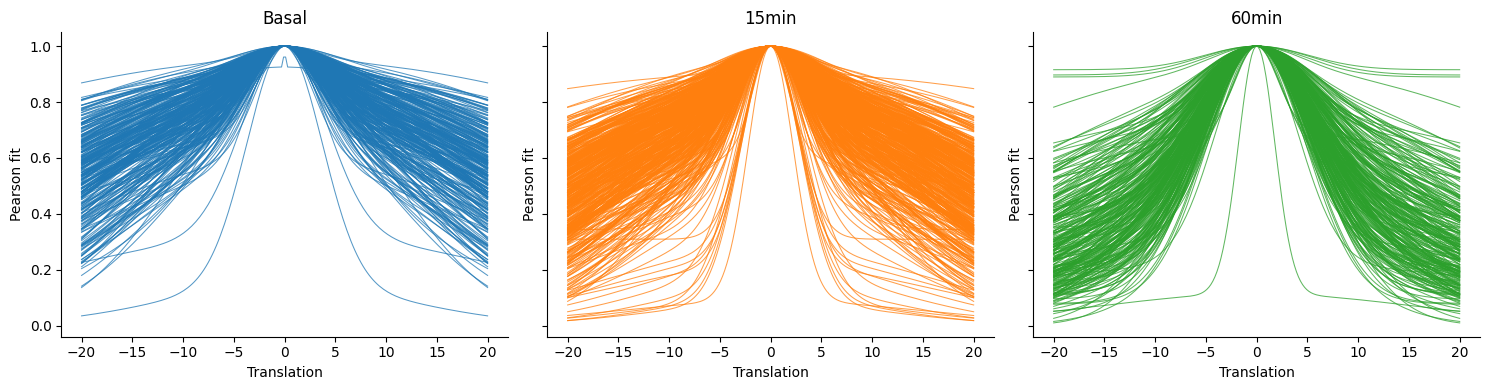

In [35]:
#@title Generate curves to visualize all fits.

# Generate fitted curves

x_grid = np.linspace(
    data_filtered["Translation"].min(),
    data_filtered["Translation"].max(),
    200
)

fit_curves = []

for _, row in results2.dropna().iterrows():

    y_fit = double_gaussian(
        x_grid,
        row["A"],
        row["sigma1"],
        row["sigma2"]
    )

    temp = pd.DataFrame({
        "Translation": x_grid,
        "Pearson_fit": y_fit,
        "Condition": row["Condition"],
        "ROI": row["ROI"]
    })

    fit_curves.append(temp)

fits_df2 = pd.concat(
    fit_curves,
    ignore_index=True
)

import math

# Get conditions actually present in the fitted data
conditions = fits_df2["Condition"].dropna().unique()

# Number of columns
n_cols = 3
n_rows = math.ceil(len(conditions) / n_cols)

# Create subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True
)

# Make axes iterable
axes = axes.flatten()

# Plot each condition
for ax, cond in zip(axes, conditions):

    condition_data = fits_df2[
        fits_df2["Condition"] == cond
    ]

    # Plot one fitted curve per ROI
    for roi, df_sub in condition_data.groupby("ROI"):

        ax.plot(
            df_sub["Translation"],
            df_sub["Pearson_fit"],
            alpha=0.75,
            linewidth=0.75,
            color=colors.get(cond, "gray")
        )

    ax.set_title(str(cond))
    ax.set_xlabel("Translation")
    ax.set_ylabel("Pearson fit")

    sns.despine(ax=ax)

# Hide unused subplots
for ax in axes[len(conditions):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 6. Calculate FWHM

In [36]:
#@title Calculate FWHM from the double Gaussian fits

from scipy.optimize import root_scalar

def compute_fwhm_model(A, sigma1, sigma2):

    # Reject invalid inputs
    if pd.isna(A) or pd.isna(sigma1) or pd.isna(sigma2):
        return np.nan

    # Model shifted downward by 0.5
    # (equivalent to R function f)
    def f(x):
        return (
            A * np.exp(-(x**2) / (2 * sigma1**2))
            + (1 - A) * np.exp(-(x**2) / (2 * sigma2**2))
            - 0.5
        )

    # Initial upper bound
    upper = max(sigma1, sigma2) * 5

    # Expand search window safely
    while (
        not np.isnan(f(upper))
        and f(upper) > 0
        and upper < 1e4
    ):
        upper *= 2

    # No crossing found
    if np.isnan(f(upper)) or f(upper) > 0:
        return np.nan

    try:
        # Root finding
        root = root_scalar(
            f,
            bracket=[0, upper],
            method="brentq"
        ).root

        # FWHM = 2 * positive root
        return 2 * root

    except Exception:
        return np.nan


# Apply row-wise to fitted parameters
fwhm_results = results2.copy()

fwhm_results["FWHM"] = fwhm_results.apply(
    lambda row: compute_fwhm_model(
        row["A"],
        row["sigma1"],
        row["sigma2"]
    ),
    axis=1
)

print(fwhm_results.head())

          A    sigma1     sigma2 Condition                  ROI       FWHM
0  0.112962  3.204890  27.143945     Basal   C1-Basal_028_0.csv  58.130145
1  0.201545  3.482285  19.487011     Basal   C1-Basal_028_1.csv  37.709106
2  0.088495  3.127966  31.281584     Basal  C1-Basal_028_10.csv  68.562464
3  0.102590  2.836873  34.958959     Basal  C1-Basal_028_11.csv  75.621639
4  0.101222  3.922003  27.797732     Basal  C1-Basal_028_12.csv  60.209012


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 21.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


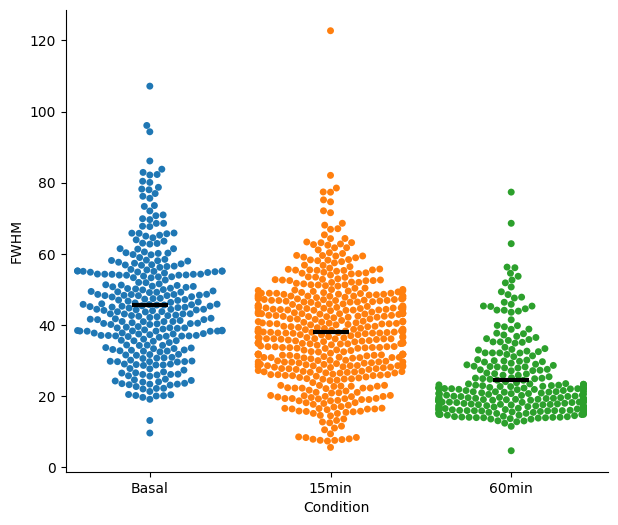

In [41]:
#@title Plot FWHM results as beeswarm plot

plt.figure(figsize=(7,6))

# Beeswarm
sns.swarmplot(
    data=fwhm_results,
    x="Condition",
    y="FWHM",
    hue="Condition",
    palette=colors,
    dodge=False,
    size=5
)

# Mean bar
means = (
    fwhm_results
    .groupby("Condition", observed=False)["FWHM"]
    .mean()
)

for i, cond in enumerate(condition_names):

    if cond in means.index and not pd.isna(means[cond]):

        plt.scatter(
            i,
            means[cond],
            marker="_",   # horizontal line
            s=700,
            linewidth=3,
            color="black",
            zorder=10
        )

# Labels
plt.xlabel("Condition")
plt.ylabel("FWHM")

# Remove legend
plt.legend([], [], frameon=False)
sns.despine()

plt.savefig(
    os.path.join(path, "FWHM_by_condition.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
#@title Export fit results dataframe.

# Output folder
output_path = path  # same folder as input files

# Output filename
csv_file = os.path.join(
    output_path,
    "double_gaussian_fit_results.csv"
)

# Select columns to export
export_df = fwhm_results[
    [
        "Condition",
        "ROI",
        "A",
        "sigma1",
        "sigma2",
        "FWHM"
    ]
].copy()

# Export CSV
export_df.to_csv(
    csv_file,
    index=False
)